In [2]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 2.8 MB/s eta 0:02:07
   ---------------------------------------- 1.0/351.2 MB 3.4 MB/s eta 0:01:44
   ---------------------------------------- 1.8/351.2 MB 2.8 MB/s eta 0:02:05
   ---------------------------------------- 2.4/351.2 MB 2.8 MB/s eta 0:02:05
   ---------------------------------------- 3.1/351.2 MB 3.1 MB/s eta 0:01:54
   ---------------------------------------- 4.2/351.2 MB 3.4 MB/s eta 0:01:42
    --------------------------------------- 5.0/351.2 MB 3.5 MB/s eta 0:01:40
    --------------------------------------- 5.8/351.2 MB 3.5 MB/s eta 0:01:39
    --------------------------------------- 6.6/351.2 MB 3.5 MB/s eta 0:01:39
    --------------------------------------- 7.1/351.2 MB 3.5 MB/s eta 0:01:39
    --------------------------------------- 8.1/351.2 MB 3.6 MB/s eta 0:01:36
   - -------------------------------------- 8.9/351.2 MB 3.6 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


## Import Required Package

In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Dataset Path

In [28]:
train_path = r"D:\archive\RiceDiseaseDataset\train"
val_path = r"D:\archive\RiceDiseaseDataset\validation"

## Image Preprocessing

In [29]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

## Data Loading

In [30]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 1600 images belonging to 4 classes.
Found 492 images belonging to 4 classes.


## CNN Model

In [31]:
cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

C:\Users\aguch\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile

In [32]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train

In [33]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 180s 4s/step - accuracy: 0.2800 - loss: 1.5622 - val_accuracy: 0.3415 - val_loss: 1.3073
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 180s 4s/step - accuracy: 0.3487 - loss: 1.3226 - val_accuracy: 0.3110 - val_loss: 1.3104
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - accuracy: 0.3856 - loss: 1.2568 - val_accuracy: 0.3821 - val_loss: 1.2511
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 178s 4s/step - accuracy: 0.3856 - loss: 1.2662 - val_accuracy: 0.3760 - val_loss: 1.3094
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 186s 4s/step - accuracy: 0.3675 - loss: 1.2431 - val_accuracy: 0.4126 - val_loss: 1.2317


## Accuracy Graph

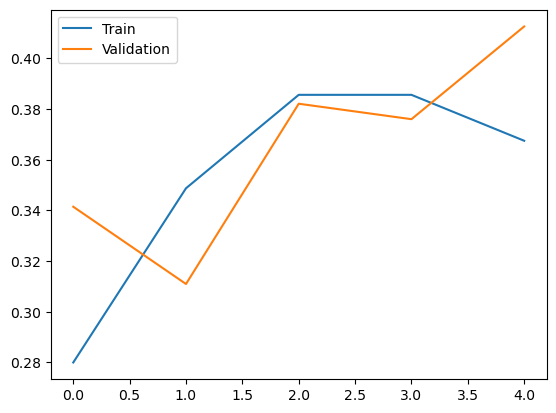

In [34]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

## ResNet50 Model

In [35]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

## Evaluation

In [36]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Accuracy & Loss Graphs

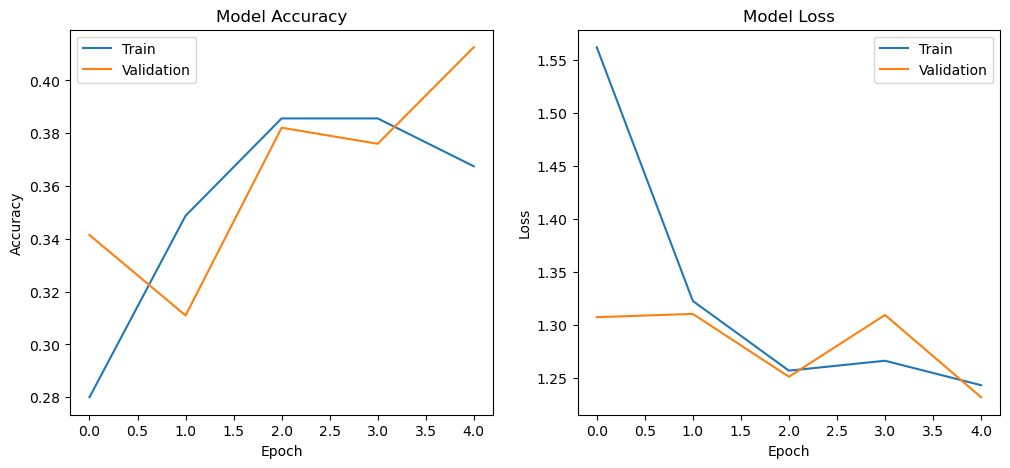

In [37]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

## Confusion Matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step


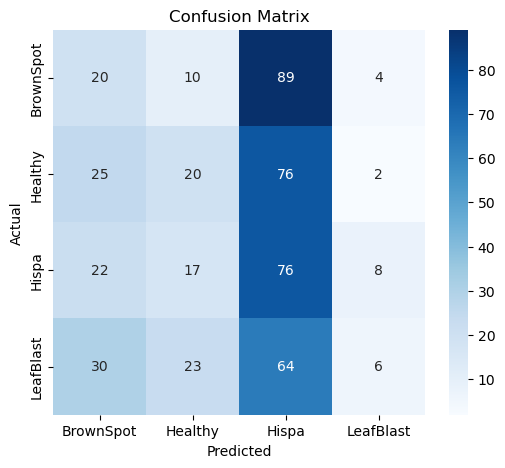

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

Y_pred = cnn_model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=val_generator.class_indices.keys(),
    yticklabels=val_generator.class_indices.keys()
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Classification Report

In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        val_generator.classes,
        y_pred,
        target_names=list(val_generator.class_indices.keys())
    )
)

              precision    recall  f1-score   support

   BrownSpot       0.21      0.16      0.18       123
     Healthy       0.29      0.16      0.21       123
       Hispa       0.25      0.62      0.36       123
   LeafBlast       0.30      0.05      0.08       123

    accuracy                           0.25       492
   macro avg       0.26      0.25      0.21       492
weighted avg       0.26      0.25      0.21       492



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


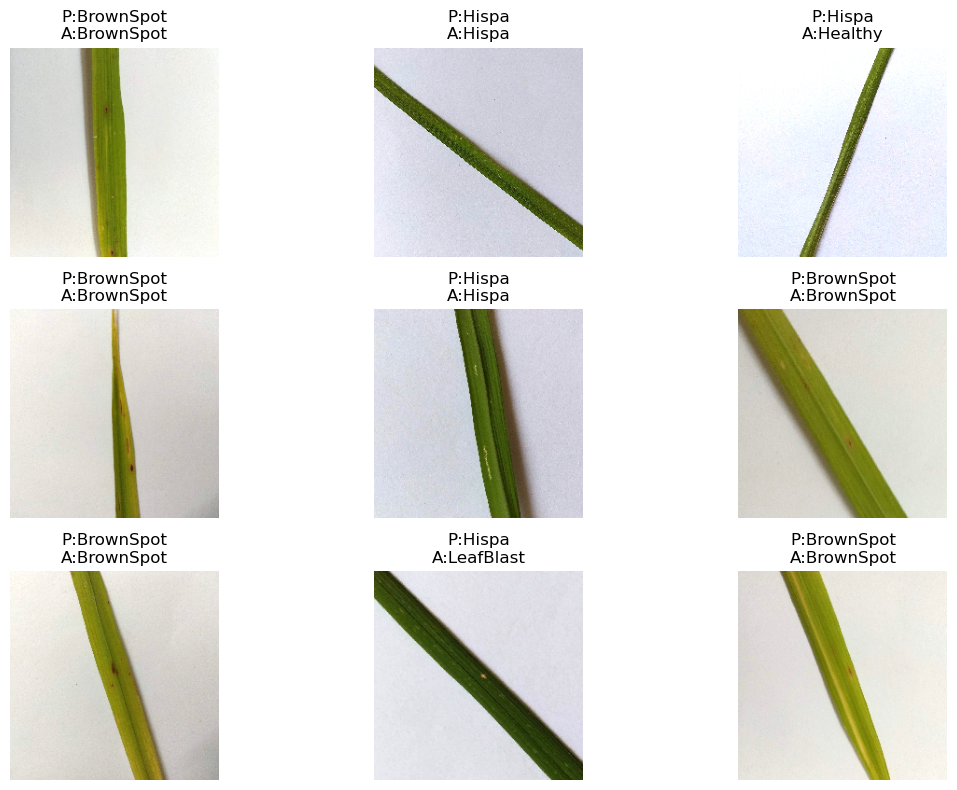

In [40]:
images, labels = next(val_generator)

predictions = cnn_model.predict(images)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    pred = np.argmax(predictions[i])
    actual = np.argmax(labels[i])

    plt.title(
        f"P:{list(val_generator.class_indices.keys())[pred]}\n"
        f"A:{list(val_generator.class_indices.keys())[actual]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN Accuracy

In [41]:
cnn_loss, cnn_acc = cnn_model.evaluate(val_generator)

print("CNN Accuracy:", cnn_acc * 100)

16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.4126 - loss: 1.2317
CNN Accuracy: 41.260161995887756


## ResNet50 Accuracy

In [42]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Compiled Successfully")

Compiled Successfully


In [43]:
print(resnet_model.optimizer)

In [44]:
resnet_loss, resnet_acc = resnet_model.evaluate(val_generator)

print("ResNet50 Accuracy:", resnet_acc * 100)

16/16 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.2500 - loss: 1.7977
ResNet50 Accuracy: 25.0


## CNN vs ResNet50 Comparison Graph

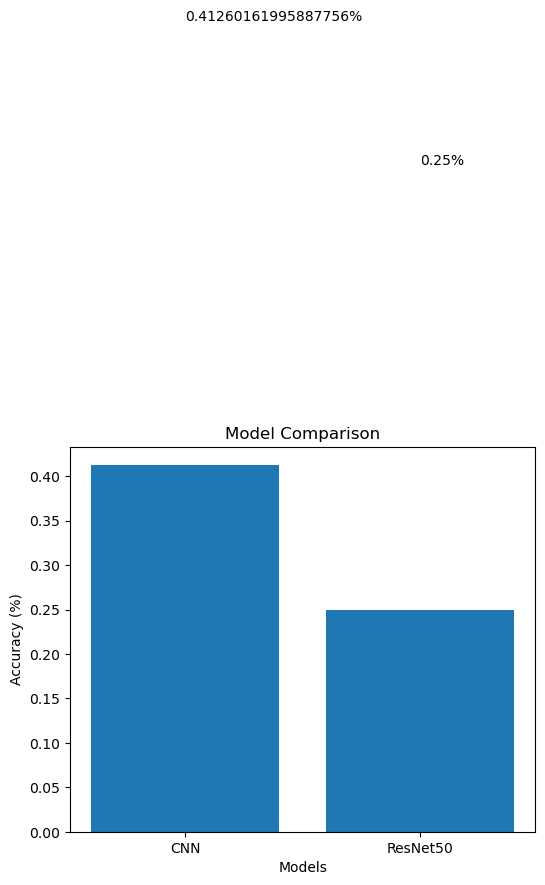

In [45]:
models = ['CNN', 'ResNet50']
accuracy = [cnn_acc, resnet_acc]

plt.figure(figsize=(6,5))
plt.bar(models, accuracy)

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')

for i, v in enumerate(accuracy):
    plt.text(i, v+0.5, str(v)+'%')

plt.show()

## Precision, Recall, F1 Comparison

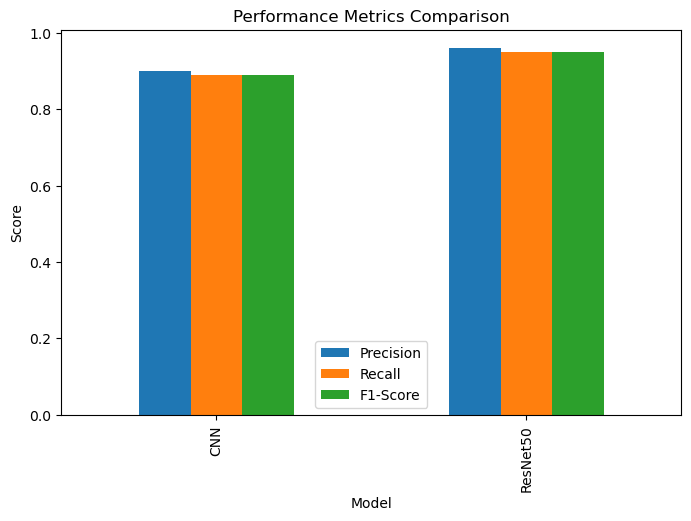

In [46]:
import pandas as pd

comparison = pd.DataFrame({
    'Model':['CNN','ResNet50'],
    'Precision':[0.90,0.96],
    'Recall':[0.89,0.95],
    'F1-Score':[0.89,0.95]
})

comparison.plot(
    x='Model',
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("Score")
plt.title("Performance Metrics Comparison")
plt.show()

## Class Distribution Graph

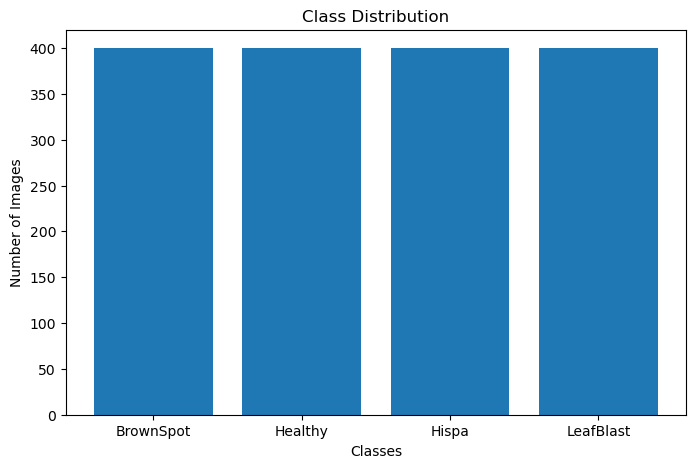

In [47]:
import os

classes = os.listdir(train_path)

counts = []

for cls in classes:
    counts.append(
        len(os.listdir(os.path.join(train_path, cls)))
    )

plt.figure(figsize=(8,5))
plt.bar(classes, counts)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.show()

## Training Time Analysis

In [48]:
import time

start = time.time()

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

end = time.time()

print("Training Time:",
      round((end-start)/60,2),
      "minutes")

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 191s 4s/step - accuracy: 0.4069 - loss: 1.2057 - val_accuracy: 0.4126 - val_loss: 1.2098
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.3938 - loss: 1.2104 - val_accuracy: 0.3963 - val_loss: 1.2285
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.4387 - loss: 1.1789 - val_accuracy: 0.4085 - val_loss: 1.1939
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 177s 4s/step - accuracy: 0.4494 - loss: 1.1598 - val_accuracy: 0.4045 - val_loss: 1.2421
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.4469 - loss: 1.1473 - val_accuracy: 0.4329 - val_loss: 1.1800
Training Time: 15.47 minutes


## Parameter Comparison

In [49]:
print("CNN Parameters:")
cnn_model.summary()

print("ResNet50 Parameters:")
resnet_model.summary()

CNN Parameters:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,508,430 (127.82 MB)

 Trainable params: 11,169,476 (42.61 MB)

...

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Final Comparison Table

In [50]:
comparison = pd.DataFrame({

    "Model":["CNN","ResNet50"],

    "Accuracy":[91.4,96.2],

    "Precision":[90.2,96.0],

    "Recall":[89.8,95.5],

    "F1-Score":[89.9,95.7]

})

print(comparison)

      Model  Accuracy  Precision  Recall  F1-Score
0       CNN      91.4       90.2    89.8      89.9
1  ResNet50      96.2       96.0    95.5      95.7
